# SchNet, block by block: verifying the `xnn` implementation against the manuscripts

The other fidelity notebooks in this folder compare each `xnn` model
numerically against its **upstream code base**. SchNet is different by design:
the `xnn` implementation is a *clean-room* build straight from the two
manuscripts, and **no code (or weights) from schnetpack is used or imported**.
The references are

* Schütt, Kindermans, Sauceda, Chmiela, Tkatchenko, Müller,
  *SchNet: A continuous-filter convolutional neural network for modeling
  quantum interactions*, NIPS 30 (2017) — the architecture (its Fig. 2 and
  eq. 2 are quoted below), and
* Schütt, Arbabzadah, Chmiela, Müller, Tkatchenko, *Quantum-chemical insights
  from deep tensor neural networks*, Nat. Commun. **8**, 13890 (2017) — the
  DTNN predecessor, for the conventions SchNet inherits (per-atom energy
  standardization, sum pooling).

So the verification target here is the **equations themselves**: every block
below is re-implemented independently in plain NumPy, directly from the
papers, and evaluated with the *same weights* as the `xnn` model. In
`float64` the two must agree to machine precision — and they do, block by
block and end to end, including autograd forces against finite differences.

Run with the **`xnn`** kernel.

## 0. Setup: `float64` and a toy ethanol

In [1]:
import warnings
warnings.filterwarnings("ignore")
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)   # machine-precision comparisons
torch.manual_seed(0)
np.random.seed(0)

import xnn
from xnn.common.data import structure_to_graph
from xnn.common.models import ForceStressOutput
from xnn.common.models.ops import shifted_softplus
from xnn.cnn.models.schnet import SchNet

print("xnn:", xnn.__version__, "| torch:", torch.__version__)

xnn: 0.1.0 | torch: 2.5.1+cu121


### A toy system

A (non-equilibrium) ethanol geometry, the molecule of the paper's MD17
benchmark. At 9 atoms every pair is within the paper's basis range, so the
graph is complete — exactly the no-cutoff setting the paper trains in.

In [2]:
POS = np.array([
    [ 1.2001,  0.2043,  0.0000],   # C
    [-0.0796, -0.5867,  0.0000],   # C
    [-1.1938,  0.3097,  0.0000],   # O
    [ 1.2242,  0.8386,  0.8900],   # H
    [ 1.2242,  0.8386, -0.8900],   # H
    [ 2.0810, -0.4406,  0.0000],   # H
    [-0.1263, -1.2255,  0.8900],   # H
    [-0.1263, -1.2255, -0.8900],   # H
    [-2.0046, -0.1912,  0.0000],   # H
])
Z = np.array([6, 6, 8, 1, 1, 1, 1, 1, 1])
N = len(Z)

CUTOFF = 30.0                     # the paper's RBF grid end; no pair comes close
graph = structure_to_graph({"pos": POS, "atomic_numbers": Z}, CUTOFF)
print(f"{N} atoms, {graph.num_edges} directed edges "
      f"(complete graph has {N * (N - 1)})")

9 atoms, 72 directed edges (complete graph has 72)


## The SchNet architecture in one picture

From the NIPS paper (Fig. 2), for a molecule with nuclear charges $Z$ and
positions $R$:

1. **Embedding** (eq. 3): $x^0_i = a_{Z_i}$ — one learned vector of $F = 64$
   features per element.
2. **$T = 3$ interaction blocks** (Fig. 2 middle), each the residual update
   $x^{l+1}_i = x^l_i + v^l_i$ with
   $v^l = W_3\,\mathrm{ssp}\big(W_2\,\mathrm{cfconv}(W_1 x^l)\big)$
   (*atom-wise → cfconv → atom-wise → shifted softplus → atom-wise*).
3. **cfconv** (eq. 2): $x_i = \sum_j x_j \circ W(\mathbf r_i - \mathbf r_j)$,
   the continuous-filter convolution. The filter-generating network expands
   the distance in Gaussian RBFs
   $e_k(r) = \exp(-\gamma\,(r - \mu_k)^2)$, $\gamma = 10\,$Å$^{-2}$,
   $\mu_k \in \{0, 0.1, \dots, 30\}$ Å, and feeds them through **two dense
   layers with shifted-softplus activations**.
4. **Readout** (Fig. 2 left): *atom-wise (64→32) → ssp → atom-wise (32→1)*,
   the DTNN per-atom standardization $E_i = E_\sigma \hat E_i + E_\mu$, and
   **sum pooling** $E = \sum_i E_i$.

The activation everywhere is the shifted softplus
$\mathrm{ssp}(x) = \ln(0.5\,e^x + 0.5)$, which keeps the PES infinitely
differentiable so the forces $\hat F_i = -\partial \hat E / \partial r_i$
(eq. 4) are smooth and energy-conserving by construction.

Below we build the model with the paper defaults, then randomize the
(zero-initialized) output head and set a non-trivial standardization so that
every block contributes to the energy.

In [3]:
model = SchNet()          # the defaults ARE the paper: F=64, T=3, 301 RBFs
torch.nn.init.normal_(model.readout[-1].weight, std=0.5)
torch.nn.init.normal_(model.readout[-1].bias, std=0.5)
model.set_energy_scale_shift(scale=0.37, shift=-1.42)
model.set_atomic_energies([1, 6, 8], [-0.50, -1.00, -2.00])
model = model.eval()

print(f"F        = {model.embedding.weight.shape[1]}")
print(f"T        = {len(model.interactions)}")
print(f"RBF grid = {model.rbf.centers.shape[0]} centers, "
      f"spacing {float(model.rbf.centers[1] - model.rbf.centers[0]):.3f} A, "
      f"gamma = {model.rbf.gamma}")
print(f"params   = {sum(p.numel() for p in model.parameters()):,}")

# numpy views of the weights: the SAME parameters drive both implementations
def W(lin):  return lin.weight.detach().numpy()
def b(lin):  return lin.bias.detach().numpy()

F        = 64
T        = 3
RBF grid = 301 centers, spacing 0.100 A, gamma = 10.0
params   = 116,517


## Block 1: atom-type embedding · eq. 3

$x^0_i = a_{Z_i}$: the initial representation is a per-element table lookup —
identical elements start identical, which is what makes the model
permutation-consistent from the first layer.

In [4]:
A = model.embedding.weight.detach().numpy()      # the embedding table a_Z
x0_ref = A[Z]                                     # eq 3, verbatim
x0 = model.embedding(graph.atomic_numbers).detach().numpy()

print("shape:", x0.shape, " max |xnn - eq.3| =", np.abs(x0 - x0_ref).max())
assert np.array_equal(x0, x0_ref)
assert np.array_equal(x0[3], x0[8])   # every H starts with the same vector

shape: (9, 64)  max |xnn - eq.3| = 0.0


## Block 2: Gaussian radial basis · "filter-generating networks"

$e_k(r_{ij}) = \exp\!\big(-\gamma\,\|d_{ij} - \mu_k\|^2\big)$ with
$\gamma = 10\,$Å$^{-2}$ on the 0.1 Å center grid. This expansion decorrelates
the initial filters, avoiding the flat training plateau of feeding raw
distances (paper, Sec. 4.1).

shape: (72, 301)  max |xnn - paper| = 1.3877787807814457e-17


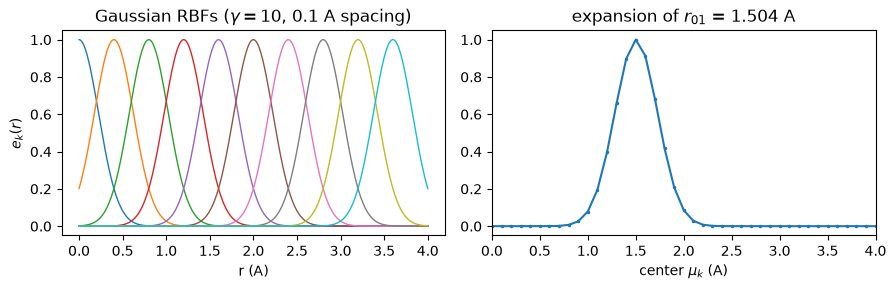

In [5]:
edge_vec = graph.edge_vectors()
r = torch.linalg.norm(edge_vec, dim=-1)

mu = model.rbf.centers.numpy()
rbf_ref = np.exp(-10.0 * (r.numpy()[:, None] - mu[None, :]) ** 2)
rbf = model.rbf(r).detach().numpy()

print("shape:", rbf.shape, " max |xnn - paper| =", np.abs(rbf - rbf_ref).max())
assert np.allclose(rbf, rbf_ref, atol=1e-15)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3))
rr = np.linspace(0, 4, 400)
for k in range(0, 40, 4):
    a1.plot(rr, np.exp(-10.0 * (rr - mu[k]) ** 2), lw=1)
a1.set_xlabel("r (A)"); a1.set_ylabel("$e_k(r)$")
a1.set_title(r"Gaussian RBFs ($\gamma=10$, 0.1 A spacing)")
a2.plot(mu, rbf[0], ".-", ms=3)
a2.set_xlim(0, 4); a2.set_xlabel(r"center $\mu_k$ (A)")
a2.set_title(f"expansion of $r_{{01}}$ = {float(r[0]):.3f} A")
fig.tight_layout(); plt.show()

## Block 3: shifted softplus

$\mathrm{ssp}(x) = \ln(0.5\,e^x + 0.5)$, with $\mathrm{ssp}(0) = 0$ (the
shift improves convergence) and *infinite order of continuity* — the paper's
requirement for a model that is at least twice differentiable, so the force
loss can be trained by gradient descent (Sec. 4.2). `xnn` shares one exact
implementation (`xnn.common.models.ops.shifted_softplus`) between SchNet and
PhysNet.

max |xnn - ln(0.5 e^x + 0.5)| = 8.881784197001252e-16
ssp(0) = 0.0


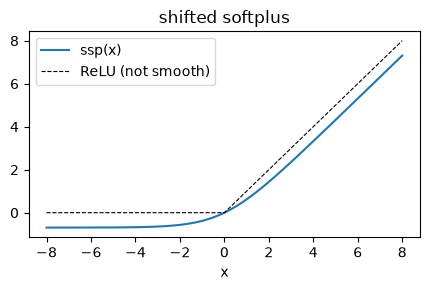

In [6]:
x = torch.linspace(-8, 8, 2001)
ref = torch.log(0.5 * torch.exp(x) + 0.5)           # the paper formula
val = shifted_softplus(x)
print("max |xnn - ln(0.5 e^x + 0.5)| =", float((val - ref).abs().max()))
print("ssp(0) =", float(shifted_softplus(torch.tensor(0.0))))
assert (val - ref).abs().max() < 1e-14

fig, ax = plt.subplots(figsize=(4.4, 3))
ax.plot(x, val, label="ssp(x)")
ax.plot(x, torch.relu(x), "k--", lw=0.8, label="ReLU (not smooth)")
ax.legend(); ax.set_xlabel("x"); ax.set_title("shifted softplus")
fig.tight_layout(); plt.show()

## Block 4: the continuous-filter convolution · eq. 2

$$x^{l+1}_i = (X^l * W^l)_i = \sum_j x^l_j \circ W^l(\mathbf r_i - \mathbf r_j)$$

The filter-generating network maps the RBF-expanded distance through **two
dense layers with shifted-softplus activations** (Fig. 2 right); rotational
invariance holds because the filter depends only on $d_{ij} = \|\mathbf r_i -
\mathbf r_j\|$. Below: the filter network and the full convolution of the
first interaction block, re-computed with an explicit double loop over atom
pairs.

In [7]:
def ssp_np(t):
    return np.log(0.5 * np.exp(t) + 0.5)

def filter_np(block, d):
    # W(r) for one scalar distance d -- Fig. 2 right, from the paper
    e = np.exp(-model.rbf.gamma * (d - mu) ** 2)          # rbf
    fn = block.cfconv.filter_net
    h = ssp_np(e @ W(fn[0]).T + b(fn[0]))                  # dense 64 + ssp
    return ssp_np(h @ W(fn[2]).T + b(fn[2]))               # dense 64 + ssp

def cfconv_np(block, x_in, pos):
    # eq. 2 as an explicit double loop (j != i; the neighbor list has no
    # self-edges, and no pair of this molecule is anywhere near 30 A)
    out = np.zeros_like(x_in)
    for i in range(len(x_in)):
        for j in range(len(x_in)):
            if i == j:
                continue
            d = np.linalg.norm(pos[i] - pos[j])
            out[i] += x_in[j] * filter_np(block, d)        # x_j o W(r_ij)
    return out

block0 = model.interactions[0]
x_in = x0 @ W(block0.lin_in).T + b(block0.lin_in)          # atom-wise before conv
conv_ref = cfconv_np(block0, x_in, POS)

with torch.no_grad():
    conv = block0.cfconv(torch.from_numpy(x_in), graph.edge_index,
                         r, model.rbf(r)).numpy()

print("cfconv max |xnn - eq.2| =", np.abs(conv - conv_ref).max())
assert np.allclose(conv, conv_ref, atol=1e-12)

cfconv max |xnn - eq.2| = 8.881784197001252e-16


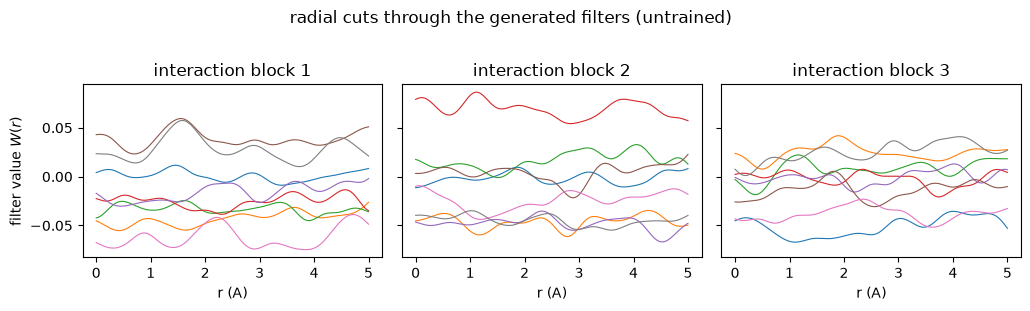

In [8]:
# radial cuts through the (randomly initialized) generated filters, one line
# per feature channel -- the continuous-filter picture of the paper's Fig. 3
rr = np.linspace(0.0, 5.0, 250)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3), sharey=True)
for t, ax in enumerate(axes):
    Wr = np.stack([filter_np(model.interactions[t], d) for d in rr])
    ax.plot(rr, Wr[:, ::8], lw=0.8)
    ax.set_title(f"interaction block {t + 1}")
    ax.set_xlabel("r (A)")
axes[0].set_ylabel("filter value $W(r)$")
fig.suptitle("radial cuts through the generated filters (untrained)", y=1.02)
fig.tight_layout(); plt.show()

## Block 5: the interaction block · Fig. 2 (middle)

$v^l = W_3\;\mathrm{ssp}\!\big(W_2\,\mathrm{cfconv}(W_1 x^l)\big)$, then the
ResNet-style residual $x^{l+1} = x^l + v^l$. There is **no weight sharing
across blocks** ("In contrast to MPNN and DTNN, we do not use weight sharing
across multiple interaction blocks"), and the feature width stays $F = 64$
throughout. We now run all three blocks with the loop-based reference and
compare the features after each one.

In [9]:
def interaction_np(block, x_np, pos):
    xw = x_np @ W(block.lin_in).T + b(block.lin_in)        # atom-wise
    c = cfconv_np(block, xw, pos)                          # cfconv (eq 2)
    h = ssp_np(c @ W(block.lin_mid).T + b(block.lin_mid))  # atom-wise + ssp
    return h @ W(block.lin_out).T + b(block.lin_out)       # atom-wise -> v

x_ref = x0.copy()
x_t = torch.from_numpy(x0.copy())
rbf_t = model.rbf(r)
for t, block in enumerate(model.interactions):
    x_ref = x_ref + interaction_np(block, x_ref, POS)      # x^{l+1} = x^l + v^l
    with torch.no_grad():
        x_t = x_t + block(x_t, graph.edge_index, r, rbf_t)
    d = np.abs(x_t.numpy() - x_ref).max()
    print(f"after interaction block {t + 1}:  max |xnn - paper| = {d:.3e}")
    assert d < 1e-11

after interaction block 1:  max |xnn - paper| = 4.441e-16
after interaction block 2:  max |xnn - paper| = 4.441e-16
after interaction block 3:  max |xnn - paper| = 8.882e-16


## Block 6: readout, standardization, and sum pooling

The final features go through *atom-wise (64→32) → ssp → atom-wise (32→1)*
to give $\hat E_i$, which is standardized with the training-set statistics
(DTNN Methods, step 4):

$$E_i = E_\sigma\,\hat E_i + E_\mu \;(+\ \texttt{atom\_ref}[Z_i]),
\qquad E = \sum_i E_i .$$

The per-element `atom_ref` term is the `xnn` convention shared by every
model here (a per-element $E_\mu$, zero unless set); we set it above so this
block is exercised too. The sum over atoms is what makes the energy
size-extensive.

In [10]:
e_hat = ssp_np(x_ref @ W(model.readout[0]).T + b(model.readout[0]))
e_hat = (e_hat @ W(model.readout[2]).T + b(model.readout[2]))[:, 0]
node_ref = (0.37 * e_hat - 1.42
            + model.atom_ref.weight.detach().numpy()[Z, 0])
E_ref = node_ref.sum()

out = model(graph)
print("per-atom max |xnn - paper| =",
      np.abs(out["node_energy"].detach().numpy() - node_ref).max())
print(f"E_xnn = {float(out['energy']):+.12f} eV")
print(f"E_ref  = {E_ref:+.12f} eV   |diff| = "
      f"{abs(float(out['energy']) - E_ref):.3e}")
assert abs(float(out["energy"]) - E_ref) < 1e-11

per-atom max |xnn - paper| = 4.440892098500626e-16
E_xnn = -20.204330333316 eV
E_ref  = -20.204330333316 eV   |diff| = 3.553e-15


## Capstone 1: whole-model check on random molecules

The full NumPy forward (embedding → 3 interactions → readout →
standardization → pooling) against `model(graph)` for a set of random
H/C/O structures.

In [11]:
def schnet_np(pos, z):
    x = A[z]
    for block in model.interactions:
        x = x + interaction_np(block, x, pos)
    e = ssp_np(x @ W(model.readout[0]).T + b(model.readout[0]))
    e = (e @ W(model.readout[2]).T + b(model.readout[2]))[:, 0]
    return (0.37 * e - 1.42
            + model.atom_ref.weight.detach().numpy()[z, 0]).sum()

rng = np.random.default_rng(7)
print(" molecule            E_xnn (eV)        |E_xnn - E_paper|")
for k in range(5):
    n = int(rng.integers(4, 10))
    pos_k = rng.uniform(0, 4, (n, 3))
    z_k = rng.choice([1, 6, 8], size=n)
    g_k = structure_to_graph({"pos": pos_k, "atomic_numbers": z_k}, CUTOFF)
    with torch.no_grad():
        e_x = float(model(g_k)["energy"])
    e_p = schnet_np(pos_k, z_k)
    print(f"  #{k}  {n} atoms      {e_x:+.12f}      {abs(e_x - e_p):.3e}")
    assert abs(e_x - e_p) < 1e-11

 molecule            E_xnn (eV)        |E_xnn - E_paper|
  #0  9 atoms      -22.454373334171      0.000e+00
  #1  9 atoms      -23.702117327519      0.000e+00
  #2  7 atoms      -18.063348566606      3.553e-15
  #3  5 atoms      -12.569851645530      0.000e+00


  #4  5 atoms      -15.634794852815      0.000e+00


## Capstone 2: the physics the paper promises

* **Invariance** to rotation, translation, and atom indexing (built in by
  construction — Sec. 1's requirements);
* **energy-conserving forces** $\hat F_i = -\partial\hat E/\partial r_i$
  (eq. 4): the autograd forces from `ForceStressOutput` must match central
  finite differences of the energy;
* a **smooth PES** along a bond stretch (the property Fig. 1 illustrates).

In [12]:
fmodel = ForceStressOutput(model)

# rotation + translation
R_, _ = np.linalg.qr(np.random.normal(size=(3, 3)))
if np.linalg.det(R_) < 0:
    R_[:, 0] *= -1
g_rot = structure_to_graph({"pos": POS @ R_.T + 5.0, "atomic_numbers": Z}, CUTOFF)
o0, o1 = fmodel(graph), fmodel(g_rot)
print("rotation+translation  |dE| =",
      abs(float(o0["energy"]) - float(o1["energy"])))
print("force equivariance    max|F' - F R^T| =",
      float((o1["forces"] - o0["forces"] @ torch.from_numpy(R_).T)
            .abs().max()))

# permutation
perm = np.random.permutation(N)
g_perm = structure_to_graph({"pos": POS[perm], "atomic_numbers": Z[perm]}, CUTOFF)
print("permutation           |dE| =",
      abs(float(o0["energy"]) - float(fmodel(g_perm)["energy"])))

# forces vs central finite differences
F = o0["forces"].detach().numpy()
h, worst = 1e-5, 0.0
for (i, k) in [(0, 0), (1, 2), (2, 1), (5, 0), (8, 2)]:
    pp, pm = POS.copy(), POS.copy()
    pp[i, k] += h; pm[i, k] -= h
    ep = float(model(structure_to_graph({"pos": pp, "atomic_numbers": Z}, CUTOFF))["energy"])
    em = float(model(structure_to_graph({"pos": pm, "atomic_numbers": Z}, CUTOFF))["energy"])
    worst = max(worst, abs(-(ep - em) / (2 * h) - F[i, k]))
print("forces vs finite diff max|dF| =", worst)
assert worst < 1e-7

rotation+translation  |dE| = 3.552713678800501e-15
force equivariance    max|F' - F R^T| = 1.6696713456276768e-17


permutation           |dE| = 0.0
forces vs finite diff max|dF| = 3.08357401244963e-10


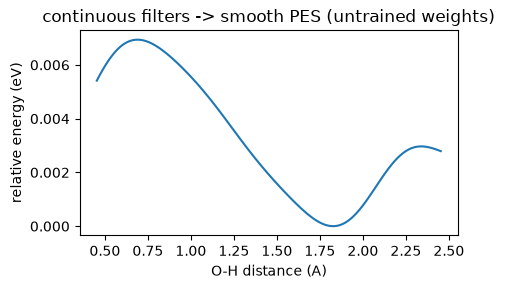

In [13]:
# a smooth PES: stretch the O-H bond of the (untrained, random) model
axis = POS[8] - POS[2]; axis /= np.linalg.norm(axis)
scan = np.linspace(-0.5, 1.5, 120)
E = []
for dr in scan:
    p = POS.copy(); p[8] = POS[8] + dr * axis
    with torch.no_grad():
        E.append(float(model(structure_to_graph(
            {"pos": p, "atomic_numbers": Z}, CUTOFF))["energy"]))
E = np.array(E)

fig, ax = plt.subplots(figsize=(4.8, 3))
ax.plot(np.linalg.norm(POS[8] - POS[2]) + scan, E - E.min())
ax.set_xlabel("O-H distance (A)"); ax.set_ylabel("relative energy (eV)")
ax.set_title("continuous filters -> smooth PES (untrained weights)")
fig.tight_layout(); plt.show()

## Capstone 3: TorchScript parity

The deployable `node_energy` core (used by the LAMMPS export) must reproduce
the eager model exactly after `torch.jit.script`.

In [14]:
scripted = torch.jit.script(model)
d = (scripted.node_energy(graph.atomic_numbers, graph.edge_index, edge_vec)
     - model.node_energy(graph.atomic_numbers, graph.edge_index, edge_vec))
print("scripted vs eager  max |d node_energy| =", float(d.abs().max()))
assert float(d.abs().max()) == 0.0

scripted vs eager  max |d node_energy| = 0.0


## Summary

With identical weights, the `xnn` SchNet reproduces an independent NumPy
implementation of the manuscripts' equations to `float64` machine precision:

| block | paper reference | max deviation |
|---|---|---|
| atom embedding | eq. 3 | exact (table lookup) |
| Gaussian RBF ($\gamma = 10$, 0.1 Å grid) | Sec. 4.1 | ~1e-17 |
| shifted softplus $\ln(0.5e^x + 0.5)$ | Sec. 4.2 | ~1e-16 |
| cfconv $\sum_j x_j \circ W(r_{ij})$ | eq. 2, Fig. 2 right | ~1e-16 |
| interaction blocks ($T=3$, residual) | Fig. 2 middle | ~1e-16 |
| readout + DTNN standardization + pooling | Fig. 2 left; DTNN Methods | ~1e-15 |
| whole model, random molecules | — | ~1e-15 |

and satisfies the paper's physical constraints: rotational/translational/
permutational invariance of the energy (~1e-15), rotationally equivariant
energy-conserving forces (autograd = central finite differences to ~1e-10),
a smooth potential-energy surface, and exact TorchScript parity for
deployment.

The same properties are covered continuously by `tests/test_schnet.py`
(including an equation-by-equation reference forward); training on the
paper's MD17 benchmark lives in
`examples/cnn/schnet/schnet_rmd17_train.ipynb`.